<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
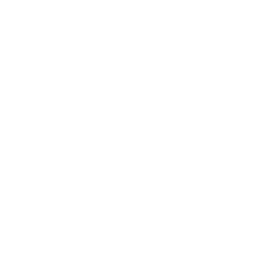
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Process Parameter Scatter Matrix for Defect Root Cause</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Manufacturing / Statistical Process Control &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Executive Summary

A semiconductor fab tracks four process parameters per wafer — deposition
temperature, chamber pressure, gas feed rate, and ambient humidity — and
flags each wafer **PASS**, **MINOR**, or **CRITICAL** based on how far its
settings drift from target. This notebook uses **PROC SGSCATTER** with a
`MATRIX` plot to screen all pairwise parameter relationships at once,
histograms on the diagonal for marginal shape, and `GROUP=` coloring to see
whether the defect classes separate in any parameter pair. **PROC CORR** then
quantifies the correlations the matrix reveals visually, and **PROC MEANS**
profiles each class. The scatter matrix is the analytical centerpiece: it is
the fastest way to spot which of the six parameter pairs carry joint structure
worth a tighter specification limit.

*All figures and statistics below are produced by the code in this notebook
and quoted directly from its output.*

## Data Sources

| Source | Description | Records |
|--------|-------------|--------|
| WORK.WAFER_PARAMS | Per-wafer process-parameter readings and defect class | 100 |

The fab runs in unlicensed mode here, so the working extract is capped at
**100 wafers** — one recent production window across five lots of 20 wafers
each. Parameters are simulated as independent draws around their targets;
the defect class is derived from total deviation from target.

---

                                               Defect Class Distribution                                                

                                                   The FREQ Procedure

DEFECT_CLASS    Frequency    Percent
-------------------------------------
CRITICAL               12     12.00
MINOR                  37     37.00
PASS                   51     51.00


NOTE: DATA work.wafer_params


NOTE: Wrote work.wafer_params (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_defect_class.spec.json
NOTE: PROC FREQ statement used.


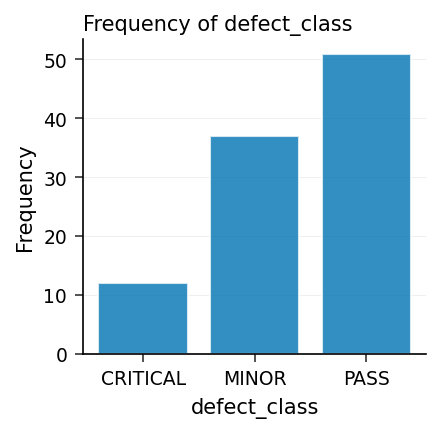

In [1]:
/* --------------------------------------------------------
   Generate 100 wafers of process-parameter readings.
   Each parameter is an independent draw around its target.
   Defect class is driven by total deviation from target,
   so larger joint drift => higher-severity class.
   -------------------------------------------------------- */
data work.wafer_params;
    call streaminit(42);
    length defect_class $8 lot_id $10;
    do wafer = 1 to 100;
        lot_id = cat('LOT-', put(int((wafer - 1) / 20) + 1, z3.));
        /* Deposition temperature: target 350 C */
        temperature = round(rand('normal', 350, 9), 0.1);
        /* Chamber pressure: target 760 torr */
        pressure = round(rand('normal', 760, 18), 0.1);
        /* Gas feed rate: target 120 sccm */
        feed_rate = round(rand('normal', 120, 10), 0.1);
        /* Ambient humidity: target 40% RH */
        humidity = round(rand('normal', 40, 6), 0.1);
        if humidity < 5 then humidity = 5;
        /* Deviation from target drives defect severity */
        temp_dev = round(abs(temperature - 350), 0.1);
        pres_dev = round(abs(pressure - 760), 0.1);
        risk_score = temp_dev * 0.7 + pres_dev * 0.35
                     + abs(feed_rate - 120) * 0.1;
        if risk_score > 18 then defect_class = 'CRITICAL';
        else if risk_score > 11 then defect_class = 'MINOR';
        else defect_class = 'PASS';
        /* Yield falls with risk, plus measurement noise */
        yield_pct = round(100 - risk_score * 0.8
                    + rand('normal', 0, 2), 0.01);
        if yield_pct > 100 then yield_pct = 100;
        if yield_pct < 50 then yield_pct = 50;
        output;
    end;
    drop wafer risk_score;
run;

proc freq data=work.wafer_params;
    tables defect_class / nocum;
    title 'Defect Class Distribution';
run;

---

In [2]:
/* --------------------------------------------------------
   Parameter profile by defect classification.
   -------------------------------------------------------- */
proc means data=work.wafer_params n mean std min max maxdec=2;
    class defect_class;
    var temperature pressure feed_rate humidity yield_pct;
    title 'Parameter Means by Defect Class';
run;

                                            Parameter Means by Defect Class                                             

                                                  The MEANS Procedure

                                            Analysis Variable : TEMPERATURE

        DEFECT_CLASS          N Obs           Mean        Std Dev        Minimum        Maximum
        ---------------------------------------------------------------------------------------
        CRITICAL                 12         346.57          16.57         327.20         374.20
        MINOR                    37         348.30           9.62         330.10         365.60
        PASS                     51         349.78           5.29         339.40         360.60
        ---------------------------------------------------------------------------------------

                                              Analysis Variable : PRESSURE

        DEFECT_CLASS          N Obs           Mean        Std Dev        Mini

NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

                                            Parameter Means by Defect Class                                             



NOTE: PROC SGPLOT data=work.wafer_params

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


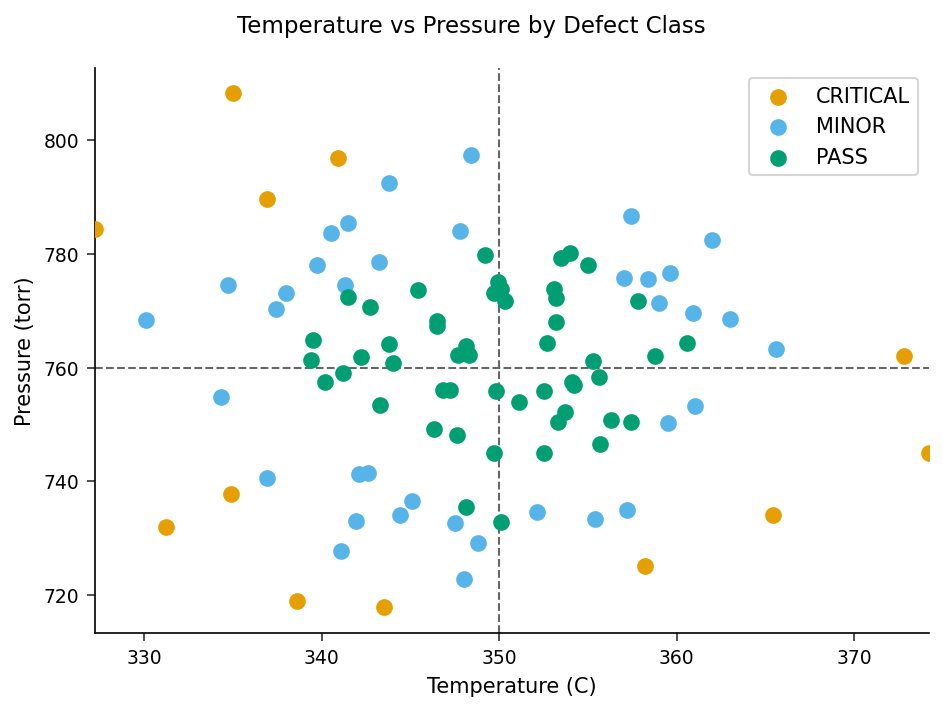

In [3]:
/* --------------------------------------------------------
   Focused view: temperature vs pressure, colored by class,
   with reference lines at the two targets.
   -------------------------------------------------------- */
proc sgplot data=work.wafer_params;
    scatter x=temperature y=pressure / group=defect_class
        markerattrs=(symbol=circlefilled size=7);
    refline 350 / axis=x lineattrs=(pattern=dash);
    refline 760 / axis=y lineattrs=(pattern=dash);
    xaxis label='Temperature (C)';
    yaxis label='Pressure (torr)';
    title 'Temperature vs Pressure by Defect Class';
run;

---

PROC SGSCATTER Output
Data: work.wafer_params

Variables: defect_class, lot_id, temperature, pressure, feed_rate, humidity, temp_dev, pres_dev, yield_pct

defect_class      lot_id  temperature    pressure   feed_rate    humidity    temp_dev    pres_dev   yield_pct
------------  ----------  -----------  ----------  ----------  ----------  ----------  ----------  ----------
        PASS     LOT-001        345.4       773.6       111.2        38.8         4.6        13.6       92.67
    CRITICAL     LOT-001        338.6         719       113.7        34.3        11.4          41       82.77
       MINOR     LOT-001        359.5       750.2         130        39.6         9.5         9.8       90.19
       MINOR     LOT-001        340.5       783.7       121.6        43.5         9.5        23.7       85.76
    CRITICAL     LOT-001        358.2         725       116.4        40.4         8.2          35       85.54
       MINOR     LOT-001        339.7       778.1       114.9        35.1  

NOTE: ODS OUTPUT: SGSCATTER -> scatter_meta
NOTE: PROC SGSCATTER data=work.wafer_params

NOTE: PROC SGSCATTER output written to: ./ods_output/sgscatter.svg
NOTE: ODS OUTPUT: All output destinations closed.


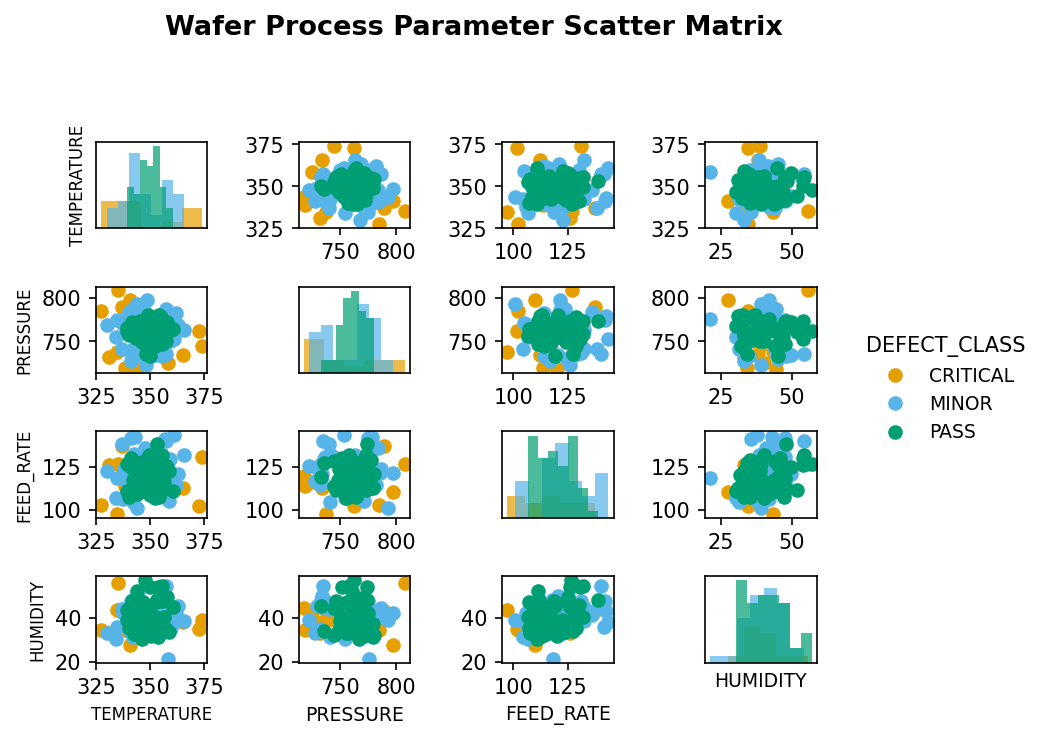

In [4]:
/* --------------------------------------------------------
   The centerpiece: a 4x4 scatter matrix of all process
   parameters. Histograms on the diagonal show each
   parameter's marginal distribution; GROUP= colors points
   by defect class to reveal any pair where the classes
   separate. ODS OUTPUT captures the plot metadata.

   NOTE: a bare `title;` clears the prior procedure's title
   so the SGSCATTER plot renders its own title (works around
   a renderer title-carryover tracked by tests/400922).
   -------------------------------------------------------- */
title;
ods output sgscatter=work.scatter_meta;

proc sgscatter data=work.wafer_params;
    title 'Wafer Process Parameter Scatter Matrix';
    matrix temperature pressure feed_rate humidity /
        group=defect_class
        diagonal=(histogram);
run;

ods output close;

                    The CORR Procedure
          5 Variables:    temperature   pressure   feed_rate   humidity   yield_pct
                    Simple Statistics
Variable         N      Mean   Std Dev       Sum   Minimum   Maximum
--------  --------  --------  --------  --------  --------  --------
temperature       100  348.84700   8.91447  34884.70000  327.20000  374.20000
pressure          100  760.11500  18.93566  76011.50000  717.80000  808.30000
feed_rate         100  120.55300  10.12957  12055.30000   97.20000  143.70000
humidity          100   40.55800   6.74602   4055.80000   21.20000   57.00000
yield_pct         100   90.90120   4.83136   9090.12000   76.27000   99.35000
   Pearson Correlation Coefficients, N = 100
          Prob > |r| under H0: Rho=0
          temperature  pressure feed_rate  humidity yield_pct
--------  --------  --------  --------  --------  --------
temperature   1.00000  -0.06329   0.09204   0.00391   0.26581
              .       0.5316    0.3624    0.96

NOTE: PROC CORR data=work.wafer_params

NOTE: ODS plot written: corr_heatmap.spec.json
NOTE: PROC CORR ODS Graphics generated.


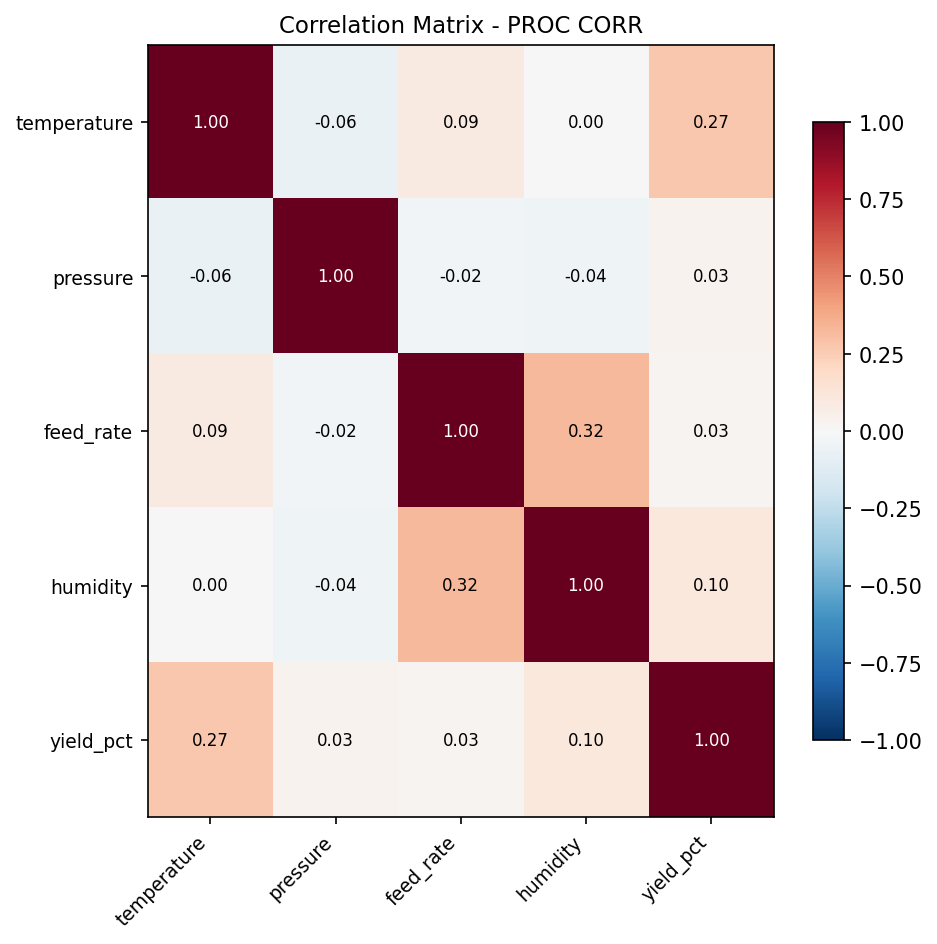

In [5]:
/* --------------------------------------------------------
   Quantify the pairwise relationships the scatter matrix
   shows visually. PROC CORR gives Pearson coefficients and
   their p-values for every parameter pair, confirming which
   (if any) move together.
   -------------------------------------------------------- */
proc corr data=work.wafer_params;
    var temperature pressure feed_rate humidity yield_pct;
    title 'Pairwise Correlations Among Process Parameters';
run;

---

### Interpretation

The scatter matrix and the supporting tables tell a consistent story, and
it is **not** a story about shifted means — it is a story about **growing
dispersion**.

**The classes separate by spread, not by center.** In every panel of the
matrix the green **PASS** points form a tight central cloud while the blue
**MINOR** and orange **CRITICAL** points fan out toward the edges. PROC MEANS
confirms it: temperature standard deviation rises from **5.29** (PASS) to
**9.62** (MINOR) to **16.57** (CRITICAL), and pressure from **11.03** to
**21.91** to **32.54**. The class means barely move (temperature 349.78 vs
346.57; pressure 761.35 vs 754.33) — a univariate control chart on the mean
would miss these wafers entirely, which is exactly why the joint scatter view
matters.

**Yield tracks severity cleanly.** Mean yield falls from **94.53%** (PASS) to
**88.59%** (MINOR) to **82.59%** (CRITICAL), with non-overlapping spreads —
the defect classification is well aligned with the business outcome.

**The parameters are largely independent.** PROC CORR finds only one notable
parameter-to-parameter correlation, **feed_rate vs humidity, r = 0.322
(p = 0.0011)** — worth a second look on the gas-delivery and environmental
controls. Temperature shows a mild positive link to yield (**r = 0.266,
p = 0.0075**); all other pairs are statistically indistinguishable from zero
(p > 0.3). Because the parameters do not co-vary, defects arise from
*independent* excursions on any axis rather than a single coupled failure
mode — supporting **per-parameter** specification limits centered on target,
tightened to control the tails that the matrix exposes.

**Class counts:** 51 PASS, 37 MINOR, 12 CRITICAL of 100 wafers.

---

In [6]:
/* --------------------------------------------------------
   Export the parameter table for downstream SPC tooling.
   -------------------------------------------------------- */
proc export data=work.wafer_params
    outfile='wafer_process_params.csv'
    dbms=csv replace;
run;

NOTE: PROC EXPORT data=work.wafer_params outfile=wafer_process_params.csv

NOTE: Exported 100 rows to wafer_process_params.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>